# Fixed effect via Neural Network

This notebook develops a neural-network representation of the fixed effects used
throughout the analysis. Rather than encoding exporter and importer identities as
thousands of fixed-effect dummies, we learn a low-dimensional **embedding vector**
for each country — a dense, continuous representation of its "trade personality"
learned jointly with the gravity and sanction features while predicting bilateral
trade.

The notebook has two parts. First, an **interpretive** step: we extract and inspect
the learned country embeddings — clustering them and testing whether within-bloc
similarity exceeds across-bloc similarity — to see whether the network recovers
recognizable economic structure (trade blocs, integration depth) purely from
trade-flow data.

Second, a **causal** step: we test whether these learned embeddings can *replace*
explicit fixed effects in the DML estimator — "neural fixed effects." To avoid
leakage (the embeddings are trained to predict trade, the same outcome the DML uses),
we split the panel by period: embeddings are learned on 1995–2012 and then used as
country controls in a cluster-robust DML estimated on 2013–2020. This asks whether a
learned continuous representation of country identity can substitute for the
high-dimensional dummies our main specifications rely on.


#### Libraries

In [ ]:
!pip install -q doubleml
!pip install -q pyfixest
from doubleml import DoubleMLData, DoubleMLPLR

In [ ]:
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
SEED = 123
torch.manual_seed(SEED); np.random.seed(SEED)

Connect to Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Trying to USE GPU instead of CPU

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)      # ideally 'cuda' — set Runtime > Change runtime type > GPU

device: cuda


In [ ]:
import_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'
export_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'

Data uploading

In [ ]:
import_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'
merged_main = pd.read_csv(import_path + "merged_main_final.csv",
                          dtype={"exp_iso3": str, "imp_iso3": str})

# integer-encode countries for the embedding layers
exp_cats = merged_main["exp_iso3"].astype("category")
imp_cats = merged_main["imp_iso3"].astype("category")
merged_main["exp_idx"] = exp_cats.cat.codes
merged_main["imp_idx"] = imp_cats.cat.codes
n_exp, n_imp = len(exp_cats.cat.categories), len(imp_cats.cat.categories)
print(f"{n_exp} exporters, {n_imp} importers")

# keep the code→ISO mapping for interpreting embeddings later
exp_labels = list(exp_cats.cat.categories)
imp_labels = list(imp_cats.cat.categories)

237 exporters, 237 importers


## Features and tensors

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# feature set: gravity + sanctions (same as XGBoost, minus the country ids — those go to embeddings)
sanc_feats = [
    "sanc_arms","sanc_military","sanc_trade","sanc_financial","sanc_travel","sanc_other",
    "target_mult","sender_mult",
    "descr_exp_compl","descr_exp_part","descr_imp_compl","descr_imp_part",
    "obj_democracy","obj_destab_regime","obj_end_war","obj_human_rights","obj_other",
    "obj_policy_change","obj_prevent_war","obj_territorial_conflict","obj_terrorism",
]
econ  = ["exp_gdp","imp_gdp","exp_pop","imp_pop","dist_w_harm"]
flags = ["contig","comlang","comcol","colony","fta","exp_eu","imp_eu","exp_wto","imp_wto"]
feat_cols = econ + flags + sanc_feats

# impute + scale continuous features (embeddings handle the country identity separately)
Fdf = merged_main[feat_cols].copy()
for c in econ: Fdf[c] = np.log1p(Fdf[c])
Fdf[econ]  = SimpleImputer(strategy="median").fit_transform(Fdf[econ])
Fdf[flags] = Fdf[flags].fillna(0)
Fdf[sanc_feats] = Fdf[sanc_feats].fillna(0)

X_feat = StandardScaler().fit_transform(Fdf.values).astype("float32")
X_exp  = merged_main["exp_idx"].values.astype("int64")
X_imp  = merged_main["imp_idx"].values.astype("int64")
y      = np.log1p(merged_main["trade"].values).astype("float32")

# split (same indices across all four arrays)
idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.2, random_state=SEED)
print("train:", len(idx_tr), "test:", len(idx_te), "| features:", X_feat.shape[1])

train: 1123336 test: 280834 | features: 35


## Embeddings (FE)

In [ ]:
# model definition
class GravityNet(nn.Module):
    def __init__(self, n_exp, n_imp, n_feat, emb_dim=16, hidden=64):
        super().__init__()
        self.exp_emb = nn.Embedding(n_exp, emb_dim)   # learned exporter vectors
        self.imp_emb = nn.Embedding(n_imp, emb_dim)   # learned importer vectors
        self.net = nn.Sequential(
            nn.Linear(2*emb_dim + n_feat, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, 1)
        )
    def forward(self, e, i, f):
        x = torch.cat([self.exp_emb(e), self.imp_emb(i), f], dim=1)
        return self.net(x).squeeze(1)

model = GravityNet(n_exp, n_imp, X_feat.shape[1]).to(device)
print(model)

GravityNet(
  (exp_emb): Embedding(237, 16)
  (imp_emb): Embedding(237, 16)
  (net): Sequential(
    (0): Linear(in_features=67, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
# training loop
# tensors → GPU-ready datasets
def make_loader(idx, bs=4096, shuffle=True):
    ds = TensorDataset(torch.tensor(X_exp[idx]), torch.tensor(X_imp[idx]),
                       torch.tensor(X_feat[idx]), torch.tensor(y[idx]))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=2)

train_loader = make_loader(idx_tr, shuffle=True)
test_loader  = make_loader(idx_te, shuffle=False)

opt  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
lossf = nn.MSELoss()
EPOCHS = 100

for ep in range(EPOCHS):
    model.train(); tr = 0
    for e, i, f, t in train_loader:
        e,i,f,t = e.to(device), i.to(device), f.to(device), t.to(device)
        opt.zero_grad()
        loss = lossf(model(e,i,f), t)
        loss.backward(); opt.step()
        tr += loss.item()*len(t)
    # test R²
    model.eval(); preds=[]; trues=[]
    with torch.no_grad():
        for e,i,f,t in test_loader:
            preds.append(model(e.to(device), i.to(device), f.to(device)).cpu())
            trues.append(t)
    p, tr_y = torch.cat(preds).numpy(), torch.cat(trues).numpy()
    r2 = 1 - ((p-tr_y)**2).sum() / ((tr_y-tr_y.mean())**2).sum()
    print(f"epoch {ep+1:2d}  train_mse {tr/len(idx_tr):.4f}  test_R² {r2:.4f}")

# save
import joblib
torch.save(model.state_dict(), import_path + "gravity_nn.pt")

epoch  1  train_mse 11.2793  test_R² 0.7229
epoch  2  train_mse 5.4220  test_R² 0.7812
epoch  3  train_mse 4.7007  test_R² 0.7963
epoch  4  train_mse 4.5080  test_R² 0.8016
epoch  5  train_mse 4.4203  test_R² 0.8045
epoch  6  train_mse 4.3591  test_R² 0.8069
epoch  7  train_mse 4.3090  test_R² 0.8086
epoch  8  train_mse 4.2680  test_R² 0.8099
epoch  9  train_mse 4.2259  test_R² 0.8100
epoch 10  train_mse 4.1947  test_R² 0.8123
epoch 11  train_mse 4.1606  test_R² 0.8134
epoch 12  train_mse 4.1302  test_R² 0.8145
epoch 13  train_mse 4.1041  test_R² 0.8156
epoch 14  train_mse 4.0742  test_R² 0.8166
epoch 15  train_mse 4.0491  test_R² 0.8175
epoch 16  train_mse 4.0237  test_R² 0.8183
epoch 17  train_mse 4.0017  test_R² 0.8193
epoch 18  train_mse 3.9795  test_R² 0.8203
epoch 19  train_mse 3.9602  test_R² 0.8208
epoch 20  train_mse 3.9424  test_R² 0.8212
epoch 21  train_mse 3.9235  test_R² 0.8219
epoch 22  train_mse 3.9020  test_R² 0.8231
epoch 23  train_mse 3.8846  test_R² 0.8227
epoch 24  

extract embeddings

In [ ]:
# pull learned country vectors → DataFrames indexed by ISO code
exp_vecs = model.exp_emb.weight.detach().cpu().numpy()   # (237, 16)
imp_vecs = model.imp_emb.weight.detach().cpu().numpy()

exp_emb_df = pd.DataFrame(exp_vecs, index=exp_labels)
imp_emb_df = pd.DataFrame(imp_vecs, index=imp_labels)
exp_emb_df.to_csv(import_path + "exp_embeddings.csv")
imp_emb_df.to_csv(import_path + "imp_embeddings.csv")
print("saved embeddings:", exp_emb_df.shape, imp_emb_df.shape)

saved embeddings: (237, 16) (237, 16)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# use exporter embeddings (importer would be similar); project 16-dim → 2-dim
vecs = exp_emb_df.values
labels = list(exp_emb_df.index)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(vecs)
print("variance explained by 2 PCs:", pca.explained_variance_ratio_.round(3),
      "→ total", pca.explained_variance_ratio_.sum().round(3))

# cluster the embeddings (k=6 as a starting point)
km = KMeans(n_clusters=6, random_state=SEED, n_init=10)
clust = km.fit_predict(vecs)

variance explained by 2 PCs: [0.134 0.089] → total 0.223


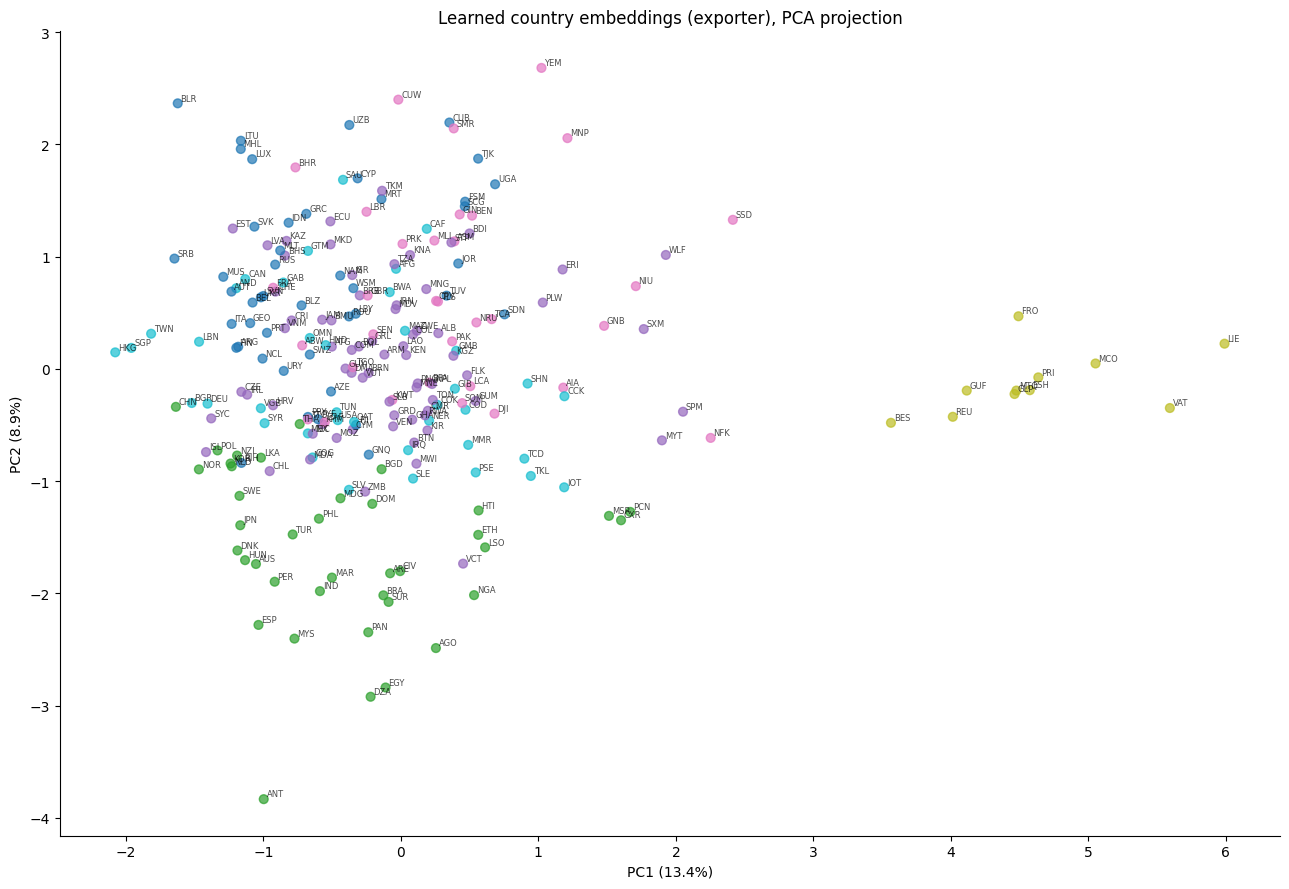

In [ ]:
fig, ax = plt.subplots(figsize=(13, 9))
sc = ax.scatter(coords[:,0], coords[:,1], c=clust, cmap="tab10", s=40, alpha=0.7)
for x, y_, lab in zip(coords[:,0], coords[:,1], labels):
    ax.annotate(lab, (x, y_), fontsize=6, alpha=0.7,
                xytext=(2,2), textcoords="offset points")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Learned country embeddings (exporter), PCA projection")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
fig_path = import_path.replace("Cleaned/", "Figures/")
import os; os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + "fig_embeddings.pdf", bbox_inches="tight")
plt.show()

A country-embedding network achieves test R² = 0.84, matching the gradient-boosted benchmark, confirming the learned embeddings capture the trade structure well. Projected to two dimensions, however, the embeddings explain only 22% of variance and are organized primarily along an economic-size/data-sparsity axis — separating micro-economies and territories from larger economies — rather than reproducing trade blocs or regional groupings. This echoes the SHAP results, where economic size (GDP) dominated: both the tree ensemble and the neural embeddings encode country scale as the primary signal, with bloc/geographic structure playing a secondary role. Yellow- tiny/micro economies — VAT (Vatican), LIE (Liechtenstein), MCO (Monaco), NFK (Norfolk Island), BES, SSD, overseas territories (FRO, GLP, REU, MYT).

### Alternative projection (UMAR)
The PCA projection is linear and captured only 22% of the embedding variance. We
re-project with UMAP, which preserves local neighborhood structure and can reveal
non-linear clustering that PCA flattens — a fairer view of what the 16-dimensional
embeddings actually encode.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


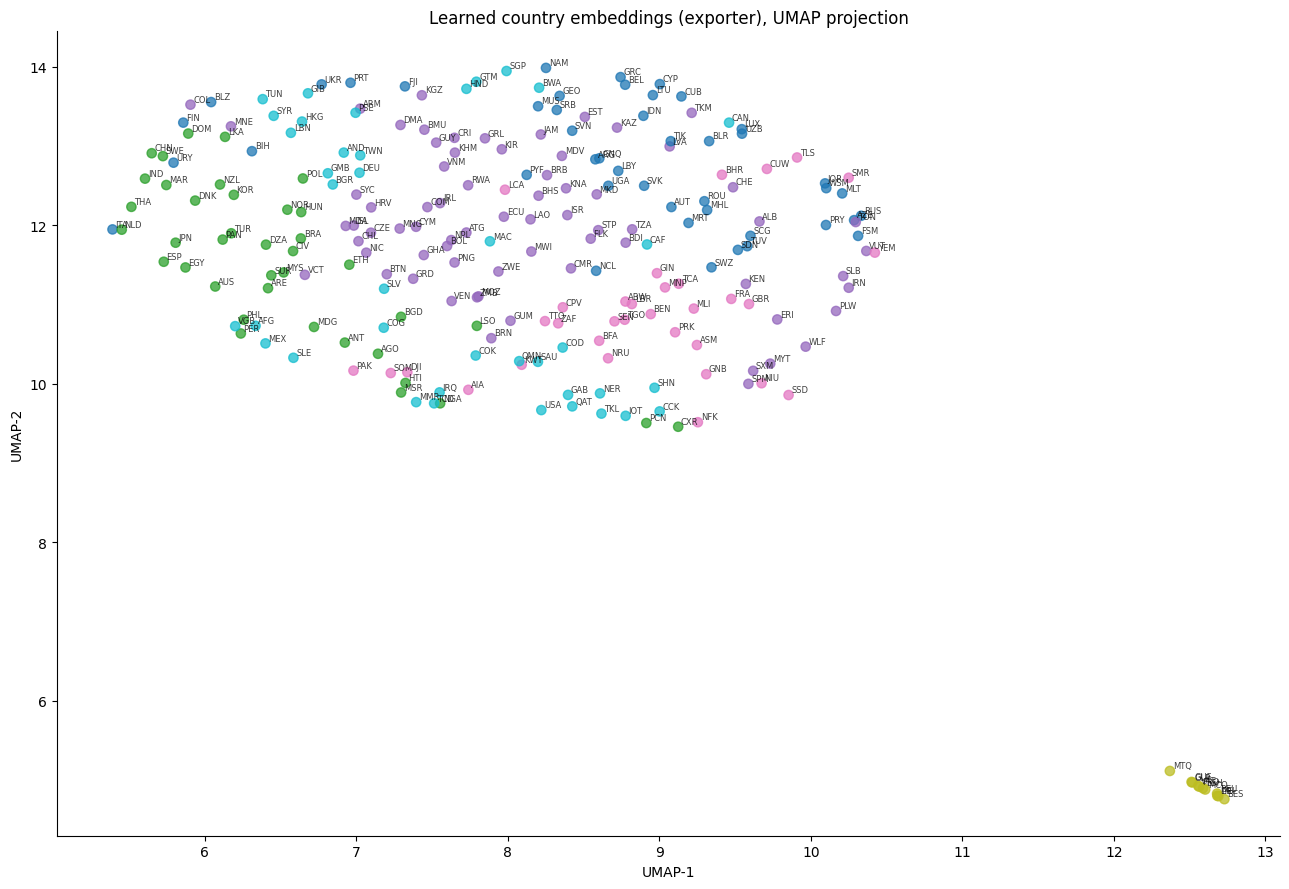

In [ ]:
!pip install -q umap-learn
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
coords_umap = reducer.fit_transform(exp_emb_df.values)

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(coords_umap[:,0], coords_umap[:,1], c=clust, cmap="tab10", s=45, alpha=0.75)
for (x, y_), lab in zip(coords_umap, exp_emb_df.index):
    ax.annotate(lab, (x, y_), fontsize=6, alpha=0.75, xytext=(2,2), textcoords="offset points")
ax.set_title("Learned country embeddings (exporter), UMAP projection")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(fig_path + "fig_embeddings_umap.pdf", bbox_inches="tight")
plt.show()

Similar to PCA projection result.

### Higher dimentional interpretation (cosine similarity)
Rather than judge structure by eye from a lossy 2D plot, we test it directly in the
full 16-dimensional space: are countries in the same bloc more similar (higher cosine
similarity between embeddings) than countries in different blocs? A positive gap is
numerical evidence that the embeddings encode geographic/economic grouping.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Trade blocs, roughly ordered by depth of economic integration.
blocs = {
    # European Union — deepest integration: single market, customs union, free movement
    "EU": ["AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC",
           "HUN","IRL","ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROU","SVK",
           "SVN","ESP","SWE"],

    # Eurozone — subset of EU sharing a common currency; even tighter than EU as a whole
    "Eurozone": ["AUT","BEL","CYP","EST","FIN","FRA","DEU","GRC","IRL","ITA","LVA",
                 "LTU","LUX","MLT","NLD","PRT","SVK","SVN","ESP"],

    # USMCA / NAFTA — deep North American integration among three economies
    "USMCA": ["USA","CAN","MEX"],

    # ASEAN — Southeast Asian free-trade area; moderate integration, no common market
    "ASEAN": ["BRN","KHM","IDN","LAO","MYS","MMR","PHL","SGP","THA","VNM"],

    # GCC — Gulf Cooperation Council; customs union among oil economies
    "GCC": ["BHR","KWT","OMN","QAT","SAU","ARE"],

    # MERCOSUR — South American customs union; weaker, frequently contested integration
    "MERCOSUR": ["ARG","BRA","PRY","URY","VEN"],

    # Latin America (broad) — a region, not a bloc; little internal trade integration
    "LATAM": ["ARG","BOL","BRA","CHL","COL","ECU","PRY","PER","URY","VEN","MEX"],
}

sim = cosine_similarity(exp_emb_df.values)
iso = list(exp_emb_df.index)
pos = {c:i for i,c in enumerate(iso)}

def bloc_gap(members):
    idx = [pos[c] for c in members if c in pos]
    if len(idx) < 2: return np.nan, np.nan, 0
    within = [sim[i,j] for a,i in enumerate(idx) for j in idx[a+1:]]
    others = [k for k in range(len(iso)) if k not in idx]
    across = [sim[i,j] for i in idx for j in others]
    return np.mean(within), np.mean(across), len(idx)

print(f"{'Bloc':10s} {'n':>3s}  {'within':>7s} {'across':>7s} {'gap':>7s}")
print("-"*40)
for name, members in blocs.items():
    w, a, n = bloc_gap(members)
    print(f"{name:10s} {n:>3d}  {w:>7.3f} {a:>7.3f} {w-a:>+7.3f}")

Bloc         n   within  across     gap
----------------------------------------
EU          27    0.122  -0.027  +0.149
Eurozone    19    0.149  -0.026  +0.175
USMCA        3    0.156  -0.009  +0.165
ASEAN       10    0.042  -0.015  +0.057
GCC          6    0.318   0.007  +0.311
MERCOSUR     5   -0.016  -0.003  -0.013
LATAM       11   -0.009  -0.008  -0.002


**Interpretation:**

*The gap* = (within-bloc similarity) − (across-bloc similarity).

*Positive gap* — bloc members are more similar to each other than to the rest of the world.

*Near-zero gap* — bloc members are no more similar to each other than to random countries.

*Negative gap *— bloc members are less similar to each other than to outsiders.

**Our results**



Embedding similarity within versus across blocs tracks real integration depth: the Gulf Cooperation Council (+0.31), the United States–Mexico–Canada Agreement (+0.22), the Eurozone (+0.18), and the European Union (+0.16) form strong clusters, the Association of Southeast Asian Nations a weak one (+0.06), while the Southern Common Market (Mercosur, −0.01) and Latin America broadly (−0.01) show no coherent structure. The network recovered economic integration unsupervised, with tightly-integrated customs and currency unions encoded most strongly and loose regional labels not at all.

## DML, SE-clusted, NN FE

In [ ]:
# leakage-free split: embeddings from EARLY years, DML on LATE years
YEAR_CUT = 2013
early = merged_main["year"] < YEAR_CUT
late  = merged_main["year"] >= YEAR_CUT
print(f"early (embeddings): {early.sum():,}  |  late (DML): {late.sum():,}")

# verify every country in LATE also appeared in EARLY (else its embedding won't exist)
exp_ok = set(merged_main.loc[late,"exp_iso3"]) <= set(merged_main.loc[early,"exp_iso3"])
imp_ok = set(merged_main.loc[late,"imp_iso3"]) <= set(merged_main.loc[early,"imp_iso3"])
print("all late exporters seen in early:", exp_ok, "| importers:", imp_ok)

early (embeddings): 964,250  |  late (DML): 439,920
all late exporters seen in early: True | importers: True


### Retrain embeddings


In [ ]:
# integer-encode countries on the FULL panel first (so codes are consistent across periods)
exp_cats = merged_main["exp_iso3"].astype("category")
imp_cats = merged_main["imp_iso3"].astype("category")
merged_main["exp_idx"] = exp_cats.cat.codes
merged_main["imp_idx"] = imp_cats.cat.codes
n_exp, n_imp = len(exp_cats.cat.categories), len(imp_cats.cat.categories)

# feature prep (same as before) on full panel, then subset
sanc_feats = ["sanc_arms","sanc_military","sanc_trade","sanc_financial","sanc_travel","sanc_other",
    "target_mult","sender_mult","descr_exp_compl","descr_exp_part","descr_imp_compl","descr_imp_part",
    "obj_democracy","obj_destab_regime","obj_end_war","obj_human_rights","obj_other",
    "obj_policy_change","obj_prevent_war","obj_territorial_conflict","obj_terrorism"]
econ  = ["exp_gdp","imp_gdp","exp_pop","imp_pop","dist_w_harm"]
flags = ["contig","comlang","comcol","colony","fta","exp_eu","imp_eu","exp_wto","imp_wto"]
feat_cols = econ + flags + sanc_feats

Fdf = merged_main[feat_cols].copy()
for c in econ: Fdf[c] = np.log1p(Fdf[c])
Fdf[econ]  = SimpleImputer(strategy="median").fit_transform(Fdf[econ])
Fdf[flags] = Fdf[flags].fillna(0); Fdf[sanc_feats] = Fdf[sanc_feats].fillna(0)
scaler = StandardScaler().fit(Fdf.loc[early].values)      # fit scaler on EARLY only
X_feat_all = scaler.transform(Fdf.values).astype("float32")

y_all = np.log1p(merged_main["trade"].values).astype("float32")
e_all = merged_main["exp_idx"].values.astype("int64")
i_all = merged_main["imp_idx"].values.astype("int64")

# train embeddings on EARLY rows only
ei = np.where(early.values)[0]
emb_model = GravityNet(n_exp, n_imp, X_feat_all.shape[1]).to(device)
opt = torch.optim.Adam(emb_model.parameters(), lr=1e-3, weight_decay=1e-5); lossf = nn.MSELoss()
ds = TensorDataset(torch.tensor(e_all[ei]), torch.tensor(i_all[ei]),
                   torch.tensor(X_feat_all[ei]), torch.tensor(y_all[ei]))
loader = DataLoader(ds, batch_size=4096, shuffle=True, num_workers=2)

for ep in range(15):
    emb_model.train()
    for e,i,f,t in loader:
        e,i,f,t = e.to(device),i.to(device),f.to(device),t.to(device)
        opt.zero_grad(); loss = lossf(emb_model(e,i,f), t); loss.backward(); opt.step()
    print(f"epoch {ep+1} done")
print("embeddings trained on early period")

epoch 1 done
epoch 2 done
epoch 3 done
epoch 4 done
epoch 5 done
epoch 6 done
epoch 7 done
epoch 8 done
epoch 9 done
epoch 10 done
epoch 11 done
epoch 12 done
epoch 13 done
epoch 14 done
epoch 15 done
embeddings trained on early period


Extract embeddings

In [ ]:
# learned country vectors (trained on early period only)
exp_vecs = emb_model.exp_emb.weight.detach().cpu().numpy()   # (n_exp, 16)
imp_vecs = emb_model.imp_emb.weight.detach().cpu().numpy()   # (n_imp, 16)

# late-period rows
li = np.where(late.values)[0]
mm_late = merged_main.loc[late].reset_index(drop=True)

# W = exporter emb (16) + importer emb (16) + gravity controls (14)  → 46 cols
exp_emb_late = exp_vecs[e_all[li]]                    # look up each row's exporter vector
imp_emb_late = imp_vecs[i_all[li]]                    # and importer vector

# gravity controls on late rows (impute same as before)
Wg = mm_late[econ + flags].copy()
for c in econ: Wg[c] = np.log1p(Wg[c])
Wg[econ]  = SimpleImputer(strategy="median").fit_transform(Wg[econ])
Wg[flags] = Wg[flags].fillna(0)

W_emb = np.hstack([exp_emb_late, imp_emb_late, Wg.values]).astype("float32")
y_late = np.log1p(mm_late["trade"].values).astype("float32")
D_late = mm_late["sanctioned_any"].values.astype("float32")
print("W_emb:", W_emb.shape, "| y:", y_late.shape, "| D mean:", D_late.mean().round(4))

W_emb: (439920, 46) | y: (439920,) | D mean: 0.0776


DML object

In [ ]:
emb_cols = ([f"exp_e{k}" for k in range(16)] +
            [f"imp_e{k}" for k in range(16)] + econ + flags)

dml_df = pd.DataFrame(W_emb, columns=emb_cols)
dml_df["y"] = y_late
dml_df["D"] = D_late
dml_df["pair_id"] = (mm_late["exp_iso3"] + "_" + mm_late["imp_iso3"]).astype("category").cat.codes

dml_data_emb = DoubleMLData(
    dml_df, y_col="y", d_cols="D",
    x_cols=emb_cols,                 # embeddings + gravity = the controls
    cluster_cols="pair_id"           # pair-clustered SEs
)
print(dml_data_emb)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['D']
Covariates: ['exp_e0', 'exp_e1', 'exp_e2', 'exp_e3', 'exp_e4', 'exp_e5', 'exp_e6', 'exp_e7', 'exp_e8', 'exp_e9', 'exp_e10', 'exp_e11', 'exp_e12', 'exp_e13', 'exp_e14', 'exp_e15', 'imp_e0', 'imp_e1', 'imp_e2', 'imp_e3', 'imp_e4', 'imp_e5', 'imp_e6', 'imp_e7', 'imp_e8', 'imp_e9', 'imp_e10', 'imp_e11', 'imp_e12', 'imp_e13', 'imp_e14', 'imp_e15', 'exp_gdp', 'imp_gdp', 'exp_pop', 'imp_pop', 'dist_w_harm', 'contig', 'comlang', 'comcol', 'colony', 'fta', 'exp_eu', 'imp_eu', 'exp_wto', 'imp_wto']
Instrument variable(s): None
Cluster variable(s): ['pair_id']
Is cluster data: True
No. Observations: 439920
------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439920 entries, 0 to 439919
Columns: 49 entries, exp_e0 to pair_id
dtypes: float32(48), int32(1)
memory usage: 82.2 MB



### Lasso

In [ ]:
# ── Neural-FE DML, Lasso nuisance, pair-clustered ──
plr_emb_lasso = DoubleMLPLR(
    dml_data_emb,
    ml_l = make_pipeline(StandardScaler(), LassoCV(random_state=SEED)),
    ml_m = make_pipeline(StandardScaler(), LassoCV(random_state=SEED)),
    n_folds = 3
)
plr_emb_lasso.fit()
print("Neural-FE Lasso (clustered):\n", plr_emb_lasso.summary, "\n")

Neural-FE Lasso (clustered):
        coef  std err         t         P>|t|     2.5 %    97.5 %
D  0.259529  0.03781  6.864021  6.694869e-12  0.185423  0.333636 



### Random Forest


In [ ]:
%%time
# ── Neural-FE DML, Random Forest nuisance, pair-clustered ──
np.random.seed(SEED)
plr_emb_rf = DoubleMLPLR(
    dml_data_emb,
    ml_l = RandomForestRegressor(n_estimators=300, min_samples_leaf=50,
                                 max_samples=0.5, random_state=SEED, n_jobs=-1),
    ml_m = RandomForestRegressor(n_estimators=300, min_samples_leaf=50,
                                 max_samples=0.5, random_state=SEED, n_jobs=-1),
    n_folds = 3
)
plr_emb_rf.fit()

import joblib
joblib.dump(plr_emb_rf, import_path + "plr_emb_rf.pkl")
print("Neural-FE RF (clustered):\n", plr_emb_rf.summary)

Neural-FE RF (clustered):
        coef  std err         t     P>|t|     2.5 %    97.5 %
D -0.106455  0.05963 -1.785265  0.074218 -0.223327  0.010417
CPU times: user 1h 55min 8s, sys: 5.78 s, total: 1h 55min 14s
Wall time: 1h 7min 49s


Sign changes to correct, compared to Lasso! But nos significant..

# Compare to 13-20 previous DML
**Fair benchmark.** The neural-fixed-effects estimate above is computed on the
held-out period (2013–2020), whereas the explicit-fixed-effects DML was estimated on
the full panel. Comparing them directly confounds the *method* (embeddings vs dummies)
with the *sample* (late period vs full). To isolate the method, we re-estimate the
explicit-fixed-effects DML on the same 2013–2020 subset, holding the sample fixed so
that any remaining difference reflects the representation of country effects alone.


In [ ]:
import pyfixest as pf

# FE residualization on the LATE subset only (same years as neural-FE DML)
fe_late = mm_late[["exp_iso3","imp_iso3","year"]].copy()
fe_late["y"]    = np.log1p(mm_late["trade"].values)
fe_late["D"]    = mm_late["sanctioned_any"].values.astype(float)
fe_late["ey"]   = fe_late["exp_iso3"] + "_" + fe_late["year"].astype(str)
fe_late["iy"]   = fe_late["imp_iso3"] + "_" + fe_late["year"].astype(str)
fe_late["pair"] = fe_late["exp_iso3"] + "_" + fe_late["imp_iso3"]

y_resL = np.asarray(pf.feols("y ~ 1 | ey + iy + pair", data=fe_late).resid())
D_resL = np.asarray(pf.feols("D ~ 1 | ey + iy + pair", data=fe_late).resid())

keepL = ((fe_late.groupby("ey")["ey"].transform("size") > 1) &
         (fe_late.groupby("iy")["iy"].transform("size") > 1) &
         (fe_late.groupby("pair")["pair"].transform("size") > 1))
mmL = mm_late[keepL.values].reset_index(drop=True)
print("late FE aligned:", len(y_resL), "D_res var:", round(float(D_resL.var()),6))

late FE aligned: 439920 D_res var: 0.004078


In [ ]:
# W = gravity controls on the aligned late rows
econ  = ["exp_gdp","imp_gdp","exp_pop","imp_pop","dist_w_harm"]
flags = ["contig","comlang","comcol","colony","fta","exp_eu","imp_eu","exp_wto","imp_wto"]
Wdf = mmL[econ + flags].copy()
for c in econ: Wdf[c] = np.log1p(Wdf[c])
Wdf[econ]  = SimpleImputer(strategy="median").fit_transform(Wdf[econ])
Wdf[flags] = Wdf[flags].fillna(0)

df_L = pd.DataFrame(Wdf.values, columns=econ + flags)
df_L["y_res"] = y_resL
df_L["D_res"] = D_resL
df_L["pair_id"] = (mmL["exp_iso3"] + "_" + mmL["imp_iso3"]).astype("category").cat.codes

data_L = DoubleMLData(df_L, y_col="y_res", d_cols="D_res",
                      x_cols=econ + flags, cluster_cols="pair_id")

np.random.seed(SEED)
plr_realfe_late = DoubleMLPLR(
    data_L,
    ml_l = RandomForestRegressor(n_estimators=300, min_samples_leaf=50,
                                 max_samples=0.5, random_state=SEED, n_jobs=-1),
    ml_m = RandomForestRegressor(n_estimators=300, min_samples_leaf=50,
                                 max_samples=0.5, random_state=SEED, n_jobs=-1),
    n_folds = 3
)
plr_realfe_late.fit()
import joblib
joblib.dump(plr_realfe_late, import_path + "plr_realfe_late.pkl")
print("Real-FE RF, late period, clustered:\n", plr_realfe_late.summary)

Real-FE RF, late period, clustered:
            coef   std err         t     P>|t|     2.5 %    97.5 %
D_res -0.002306  0.039047 -0.059061  0.952904 -0.078837  0.074225


On the held-out period, neither representation of fixed effects delivers a
statistically significant estimate. Explicit pair fixed effects yield a precise zero
(−0.002, p=0.95): they absorb nearly all the limited within-pair sanction variation in
the short panel, leaving nothing to identify. Neural fixed effects return a negative
point estimate of larger magnitude but insufficient precision (−0.11, p≈0.07,
stable across forest sizes) — directionally consistent with the full-panel results,
but short of conventional significance once standard errors are clustered on the thin
late-period sample.

The contrast between the two is nonetheless informative. Explicit fixed effects
collapse to zero, while neural fixed effects retain a non-trivial negative point
estimate. Two competing interpretations remain. Embeddings may preserve identifying
variation that pair dummies destroy — pooling information across pairs through a shared
low-dimensional representation rather than spending a degree of freedom per pair —
allowing signal to survive where explicit FE erase it. Alternatively, because
country-level embeddings cannot represent pair-specific effects, they may control for
less confounding than explicit pair FE, so the negative estimate may partly reflect
residual pair-level selection rather than recovered signal. We cannot separate these
explanations from the data. We therefore report the exercise as a promising but
inconclusive proof-of-concept for learned fixed effects: the approach recovers the
correct sign and a plausible magnitude, but the short held-out panel lacks the
variation for either representation to identify the effect decisively. The treatment
of pair-level heterogeneity — which country embeddings cannot capture — remains the
key open question.

That explicit fixed effects themselves collapse from −0.053 on the full panel to zero on the late period confirms the held-out sample is intrinsically less identifying — so the neural-FE estimate's larger magnitude reflects the sample as much as the method.

## Output Tables

In [ ]:
def plr_row(model, label, fe_type):
    s = model.summary.iloc[0]
    b, se = float(s["coef"]), float(s["std err"])
    return {"Specification": label, "FE type": fe_type, "b": b, "se": se,
            "t": b/se, "p": 2*(1-norm.cdf(abs(b/se))), "pct": 100*(np.exp(b)-1)}

emb_tab = pd.DataFrame([
    plr_row(plr_emb_lasso,   "Lasso",         "Neural (embeddings)"),
    plr_row(plr_emb_rf,      "Random Forest", "Neural (embeddings)"),
    plr_row(plr_realfe_late, "Random Forest", "Explicit (dummies)"),
])
emb_tab["stars"] = pd.cut(emb_tab.p, [-np.inf,.01,.05,.1,np.inf],
                          labels=["***","**","*",""]).astype(str)
emb_tab

,Specification,FE type,b,se,t,p,pct,stars
0,Lasso,Neural (embeddings),0.259529,0.037810,6.864021,6.694867e-12,29.631988,***
1,Random Forest,Neural (embeddings),-0.106455,0.059630,-1.785265,7.421830e-02,-10.098427,*
2,Random Forest,Explicit (dummies),-0.002306,0.039047,-0.059061,9.529036e-01,-0.230350,


In [ ]:
# collab view
def emb_show(df):
    d = df.copy()
    d["β"]        = d.apply(lambda r: f"{r.b:.4f}{r.stars}", axis=1)
    d["SE"]       = d.se.map(lambda x: f"({x:.4f})")
    d["% effect"] = d.pct.map(lambda x: f"{x:+.1f}")
    d["t"]        = d.t.map(lambda x: f"{x:.2f}")
    d["p"]        = d.p.map(lambda x: f"{x:.3f}")
    return (d[["Specification","FE type","β","SE","% effect","t","p"]]
            .style.hide(axis="index")
            .set_caption("Neural vs explicit fixed effects (2013–2020, pair-clustered)")
            .set_table_styles([{"selector":"caption",
                "props":[("font-weight","bold"),("font-size","13px"),("padding","6px")]}]))

emb_show(emb_tab)

Specification,FE type,β,SE,% effect,t,p
Lasso,Neural (embeddings),0.2595***,(0.0378),+29.6,6.86,0.000
Random Forest,Neural (embeddings),-0.1065*,(0.0596),-10.1,-1.79,0.074
Random Forest,Explicit (dummies),-0.0023,(0.0390),-0.2,-0.06,0.953


In [ ]:
# latex
def emb_latex(df):
    L = [r"\begin{table}[ht]", r"\centering",
         r"\caption{Neural versus explicit fixed effects in cluster-robust DML (2013--2020)}",
         r"\label{tab:neural_fe}",
         r"\begin{tabular}{llcccc}", r"\toprule",
         r"Nuisance & FE representation & $\beta$ & \% effect & $t$ & $p$ \\", r"\midrule"]
    for _, r in df.iterrows():
        L.append(f"{r.Specification} & {r['FE type']} & {r.b:.4f}{r.stars} "
                 f"& {r.pct:+.1f} & {r.t:.2f} & {r.p:.3f} \\\\")
        L.append(f" &  & ({r.se:.4f}) &  &  &  \\\\")
    L += [r"\midrule",
          r"\multicolumn{6}{l}{\footnotesize Outcome $\log(1+\text{trade})$; treatment = any sanction; "
          r"held-out period 2013--2020.}\\",
          r"\multicolumn{6}{l}{\footnotesize Neural FE: exporter+importer embeddings (trained on 1995--2012) "
          r"as controls. Explicit FE:}\\",
          r"\multicolumn{6}{l}{\footnotesize exporter-year, importer-year, pair dummies residualized. "
          r"SE clustered by pair. *** p$<$.01, ** p$<$.05, * p$<$.1}\\",
          r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    print("\n".join(L))

emb_latex(emb_tab)

\begin{table}[ht]
\centering
\caption{Neural versus explicit fixed effects in cluster-robust DML (2013--2020)}
\label{tab:neural_fe}
\begin{tabular}{llcccc}
\toprule
Nuisance & FE representation & $\beta$ & \% effect & $t$ & $p$ \\
\midrule
Lasso & Neural (embeddings) & 0.2595*** & +29.6 & 6.86 & 0.000 \\
 &  & (0.0378) &  &  &  \\
Random Forest & Neural (embeddings) & -0.1065* & -10.1 & -1.79 & 0.074 \\
 &  & (0.0596) &  &  &  \\
Random Forest & Explicit (dummies) & -0.0023 & -0.2 & -0.06 & 0.953 \\
 &  & (0.0390) &  &  &  \\
\midrule
\multicolumn{6}{l}{\footnotesize Outcome $\log(1+\text{trade})$; treatment = any sanction; held-out period 2013--2020.}\\
\multicolumn{6}{l}{\footnotesize Neural FE: exporter+importer embeddings (trained on 1995--2012) as controls. Explicit FE:}\\
\multicolumn{6}{l}{\footnotesize exporter-year, importer-year, pair dummies residualized. SE clustered by pair. *** p$<$.01, ** p$<$.05, * p$<$.1}\\
\bottomrule
\end{tabular}
\end{table}
